# B2.3 Linear Regression - Least Squares Method
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.1 Motivation

Linear regression is a fundamental statistical method used to model the relationship between two variables by fitting a straight line to a set of data points. The **least squares method** is the most common way to determine this best-fit line by minimizing the sum of the squared differences between the observed data points and the predicted values on the line.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.2 The Equation of a Line  

A straight line is represented by the equation:

$$
y = mx + b
$$

where:
- $ y $ is the dependent variable,
- $ x $ is the independent variable,
- $m $ is the **slope** of the line,
- $ b $ is the **y-intercept** (the value of $ y $ when $ x = 0 $).

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.3 The Least Squares Method  

The least squares method finds the values of $ m $ and $ b $ that minimize the sum of squared errors, where the **error** is the difference between the actual data point $ y_i $ and the predicted value $ \hat{y_i} $ from the line.

###  Sum of Squared Errors (SSE)  
The total squared error is given by:

$$
SSE = \sum_{i=1}^{N} (y_i - \hat{y_i})^2
$$

where:
- $ N $ is the number of data points,
- $ y_i $ are the actual observed values,
- $ \hat{y_i} = mx_i + b $ are the predicted values from the line.

The goal is to find $ m $ and $ b $ that minimize **SSE**.

### Calculating $ m $ and $ b $  
Using calculus (we will not bother to go through the process), we derive the formulas for the **slope** and **y-intercept**:

#### Slope $ m $:

$$
m = \frac{N \sum x_i y_i - \sum x_i \sum y_i}{N \sum x_i^2 - (\sum x_i)^2}
$$

#### Intercept $ b $:

$$
b = \frac{\sum y_i - m \sum x_i}{N}
$$

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.4 Example Calculation  
Consider the following dataset:

| $ x $ | $ y $ |
|----|----|
| $1$ | $2$  |
| $2$  | $3$  |
| $3$  | $5$  |
| $4$  | $7$  |
| $5$  | $11$ |

### Step 1: Compute Required Sums  

$$
\sum x_i = 1+2+3+4+5 = 15
$$

$$
\sum y_i = 2+3+5+7+11 = 28
$$

$$
\sum x_i^2 = 1^2 + 2^2 + 3^2 + 4^2 + 5^2 = 55
$$

$$
\sum x_i y_i = (1 \times 2) + (2 \times 3) + (3 \times 5) + (4 \times 7) + (5 \times 11) = 106
$$

### Step 2: Compute $ m $ and $ b $ 

#### Compute Slope:

$$
m = \frac{(5)(106) - (15)(28)}{(5)(55) - (15)^2} = 2.2
$$

#### Compute Intercept:

$$
b = \frac{28 - (2.2)(15)}{5} = -1.0
$$

### Step 3: Final Equation of the Best-Fit Line  

$$
y = 2.2x - 1.0
$$

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

### Example Script

In [ ]:
%reset -f

#script to calculate the best-fit line: y = mx + b
import numpy as np

x = np.array([1,2,3,4,5])
y = np.array([2,3,5,7,11])
N = len(x)

m = ((N*np.sum(x*y)) - (np.sum(x)*np.sum(y)))/((N*np.sum(x*x)) - (np.sum(x)**2))

b = (np.sum(y) - m*np.sum(x))/(N)

print('Best-Fit Line: y = ('+str(m)+')x + ('+str(b)+')')

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.5 Visualizing the Fit  
The computed line $ y = 0.1x + 5.3 $ represents the best-fit line that minimizes the sum of squared differences between the observed $ y $-values and the predicted values.

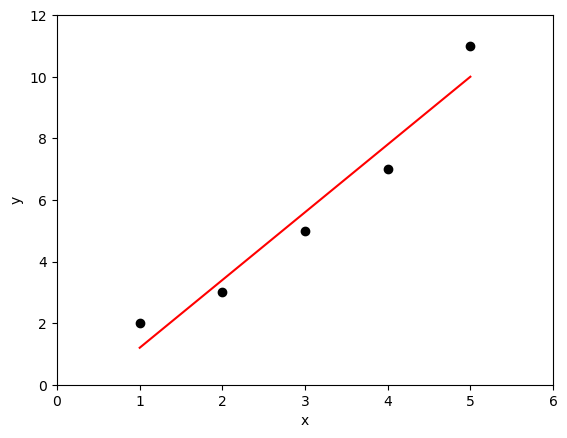

In [35]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,2,3,4,5])
y = np.array([2,3,5,7,11])

N = len(x)

m = ((N*np.sum(x*y)) - (np.sum(x)*np.sum(y)))/((N*np.sum(x*x)) - (np.sum(x)**2))
b = (np.sum(y) - m*np.sum(x))/(N)
y_fit = m*x + b

# finding minimum value for graphing
if np.min(x) < 0:
    min_x_val = np.min(x)-1
else:
    min_x_val = 0
    
if np.min(y) < 0:
    min_y_val = np.min(y)-1
else:
    min_y_val = 0

plt.figure()
plt.ylabel('y')
plt.xlabel('x')
ax = plt.gca()
ax.scatter(x,y,color='k')


ax.set_xlim([min_x_val, np.max(x)+1])
ax.set_ylim([min_y_val, np.max(y)+1])

plt.plot(x,y_fit,color='r')
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.6 Goodness of Fit  
The **goodness of fit** measures how well the regression line represents the data. One common way to quantify this is using the **coefficient of determination** ($ R^2 $), which ranges from 0 to 1. A higher $R^2$ value indicates a better fit.

$$
R^2 = 1 - \frac{SSE}{SST}
$$

where:
- $ SSE $ is the sum of squared errors,
- $ SST $ is the total sum of squares, defined as:

$$
SSE = \sum_{i=1}^{N} (y_i - \hat{y_i})^2
$$

$$
SST = \sum_{i=1}^{N} (y_i - \bar{y})^2
$$


where $\hat{y_i}$ are the predicted values from the line, and $\bar{y} $ is the mean of the observed $ y $-values.

An $ R^2 $ value close to 1 suggests that the model explains most of the variation in the dependent variable, while a value close to 0 suggests a poor fit.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.7 Correlation Coefficient  
The **correlation coefficient** ($ r $) is a measure of the strength and direction of the linear relationship between two variables. It is related to $ R^2 $ as follows:

$$
r = \sqrt{R^2}
$$

The correlation coefficient can take values between -1 and 1:
- A value of 1 indicates a perfect positive linear relationship,
- A value of -1 indicates a perfect negative linear relationship,
- A value of 0 indicates no linear relationship.

For example, if $ R^2 = 0.64 $, then the correlation coefficient $ r $ is $ \pm 0.8 $, depending on the direction of the relationship.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

### Example Script

In [39]:
%reset -f

#script to calculate the best-fit line: y = mx + b
import numpy as np

x = np.array([1,2,3,4,5])
y = np.array([2,3,5,7,11])
N = len(x)

m = ((N*np.sum(x*y)) - (np.sum(x)*np.sum(y)))/((N*np.sum(x*x)) - (np.sum(x)**2))

b = (np.sum(y) - m*np.sum(x))/(N)

y_fit = m*x + b

SSE = np.sum((y-y_fit)**2)

mean = np.sum(y)/N
SST = np.sum((y - mean)**2)

RR = 1 - SSE/SST

r = np.sqrt(RR)

print('Goodness of fit: '+str(RR))
print('Correlation Coefficient: '+str(r))

Goodness of fit: 0.9453125
Correlation Coefficient: 0.9722718241315028


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B2.3.6 Summary  
The least squares method provides a systematic approach to finding the best-fit line for a dataset by minimizing the sum of squared errors. This method is widely used in various fields, including physics, economics, and engineering, to model relationships between variables and make predictions.

Understanding linear regression is essential for analyzing trends, making predictions, and understanding the underlying patterns in data.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">